# 05 - Action History: PMAY Disposed-No

Escalation route reconstruction and regression analysis for FY **2024-2025 PMAY** complaints that were **Disposed with `benefitted = No`**. A *route* is the sequence of distinct authorities a ticket passed through, reconstructed from the action history.

Shared scaffolding (including `build_routes`, `authority_from_status`, `standardize_office`) is in `grievance_common.py`.

## Setup

In [1]:
import os
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd

from grievance_common import (
    add_time_fields, population_df, load_district_shapefile,
    standardize_districts, DISTRICT_NAME_FIX, ONLINE_MODES,
    DB_PATH, OUTPUT_DIR, FOCUS_YEAR, VALID_YEARS, PMAY_NAME, RURAL_NAME,
    STATUS_ORDER, status_group, add_mode_group,
    authority_from_status, compress_sequence, build_routes,
    standardize_office, draw_choropleth, load_action_history,
)

## Data Load and Preparation

Load the complaints and action-history tables. `df` is the prepared
complaints frame (dates parsed, financial year, resolution days, cleaned
text). `action` is the raw action-history table used for route building.

In [2]:
from grievance_common import load_complaints, load_action_history

complaints = load_complaints()
action = load_action_history()

print(f"complaints: {complaints.shape}  |  action_history: {action.shape}")

complaints: (1371288, 50)  |  action_history: (6643582, 8)


In [3]:
def prepare_complaints(complaints):
    """Prepared complaints frame: dates, FY, resolution_days, cleaned text."""
    d = complaints.copy()
    d["created_on"] = pd.to_datetime(d["created_on"], errors="coerce")
    d["resolved_on"] = pd.to_datetime(d["resolved_on"], errors="coerce")
    d = add_time_fields(d)
    d["resolution_days"] = (
        (d["resolved_on"] - d["created_on"]).dt.total_seconds()
        / (24 * 3600)
    )
    for col in ["status", "benefitted", "subcategory"]:
        if col in d.columns:
            d[col] = d[col].fillna("").astype(str).str.strip()
    return d


df = prepare_complaints(complaints)
df = df[df["custom_year"].isin(VALID_YEARS)].copy()
print(f"{len(df):,} complaints in the FY window.")

1,323,840 complaints in the FY window.


## Shared Helpers

Defined once and reused throughout: status grouping, the Online/Offline
mode split, route reconstruction from the action history, office-name
standardization, and the district choropleth.

## Filter to PMAY Disposed-No (FY 2024-2025)

The analysis frame is restricted to PMAY (`IAY/MKY/BPGY/PMAY`) tickets from the focus year that were Disposed with `benefitted = No`.

In [4]:
# Filter: PMAY, Disposed, benefitted = No, focus year.
df_pmay_no = df[
    (df["custom_year"] == FOCUS_YEAR)
    & (df["subcategory"] == PMAY_NAME)
    & (df["status"].str.lower() == "disposed")
    & (df["benefitted"].str.lower() == "no")
].copy()
print(f"PMAY Disposed-No tickets: {df_pmay_no['ticket_no'].nunique():,}")

# Build routes once; reused by every route-analysis cell below.
route_stats = build_routes(action, df_pmay_no["ticket_no"])
route_stats = route_stats.merge(
    df_pmay_no[["ticket_no", "district", "office", "dept", "resolution_days",
                "created_on"]],
    on="ticket_no", how="left")

print(f"Routes built for {len(route_stats):,} tickets.")
route_stats[["ticket_no", "route_string", "route_length",
             "resolution_days"]].head()

PMAY Disposed-No tickets: 87,852
Routes built for 87,852 tickets.


,ticket_no,route_string,route_length,resolution_days
0,C301272,"Collector, Puri → BDO, Nimapada → Collector, Puri",3,37.859537
1,C301313,"Collector, Kalahandi → BDO, Dharmagarh → Colle...",3,30.212442
2,C301333,"Collector, Jajpur → BDO, Dasarathpur → Collect...",3,24.941748
3,C301343,"Collector, Kendujhar → BDO, Saharapada → Colle...",3,14.074942
4,C301433,"Collector, Kendujhar → BDO, Talkoi → Collector...",3,335.121528


In [5]:
# Route-length distribution and resolution time by length.
length_distribution = (
    route_stats.groupby("route_length")
    .agg(ticket_count=("ticket_no", "count"),
         unique_routes=("route_tuple", "nunique"),
         mean_resolution_days=("resolution_days", "mean"),
         median_resolution_days=("resolution_days", "median"))
    .reset_index()
)
length_distribution[["mean_resolution_days", "median_resolution_days"]] = (
    length_distribution[["mean_resolution_days", "median_resolution_days"]]
    .round(0)
)
length_distribution

,route_length,ticket_count,unique_routes,mean_resolution_days,median_resolution_days
0,1,30,3,2.0,1.0
1,2,68434,349,39.0,24.0
2,3,948,483,67.0,42.0
3,4,17292,568,60.0,49.0
4,5,446,343,75.0,58.0
5,6,549,295,74.0,65.0
6,7,65,64,83.0,78.0
7,8,53,39,82.0,68.0
8,9,10,9,83.0,79.0
9,10,18,11,85.0,99.0


In [6]:
# Routes by district: count, share within district, resolution time.
route_counts_district = (
    route_stats.groupby(["district", "route_tuple"])
    .agg(ticket_count=("ticket_no", "count"),
         mean_resolution_days=("resolution_days", "mean"),
         median_resolution_days=("resolution_days", "median"))
    .reset_index()
)
for col in ["mean_resolution_days", "median_resolution_days"]:
    route_counts_district[col] = (
        route_counts_district[col].round(0).fillna(0).astype(int))
route_counts_district["route_string"] = (
    route_counts_district["route_tuple"].apply(lambda t: " \u2192 ".join(t)))
route_counts_district["route_length"] = (
    route_counts_district["route_tuple"].apply(len))

_dist_totals = (route_counts_district.groupby("district")["ticket_count"]
                .sum().reset_index(name="district_total"))
route_counts_district = route_counts_district.merge(
    _dist_totals, on="district", how="left")
route_counts_district["share_within_district"] = (
    route_counts_district["ticket_count"]
    / route_counts_district["district_total"] * 100
).round(2)
route_counts_district = (
    route_counts_district
    .sort_values("ticket_count", ascending=False)
    .reset_index(drop=True)
    [["district", "route_string", "route_length", "ticket_count",
      "share_within_district", "mean_resolution_days",
      "median_resolution_days", "district_total"]]
)
route_counts_district.head(30)

,district,route_string,route_length,ticket_count,share_within_district,mean_resolution_days,median_resolution_days,district_total
0,Angul,"Collector, Angul → BDO, Kaniha",2,2212,29.36,22,10,7535
1,Jagatsinghapur,"Collector, Jagatsinghpur → BDO, Balikuda",2,2136,37.13,17,12,5753
2,Bhadrak,"Collector, Bhadrak → BDO, Tihidi",2,2109,25.13,76,89,8393
3,Ganjam,"Collector, Ganjam → BDO, Aska",2,2059,9.85,12,10,20898
4,Ganjam,"Collector, Ganjam → BDO, Suruda",2,1934,9.25,9,5,20898
5,Ganjam,"Collector, Ganjam → BDO, Khalikote",2,1808,8.65,16,12,20898
6,Ganjam,"Collector, Ganjam → BDO,Beguniapada",2,1802,8.62,18,13,20898
7,Cuttack,"Collector, Cuttack → BDO, Narasinghpur",2,1773,20.15,45,35,8798
8,Ganjam,"Collector, Ganjam → BDO, Purusothampur",2,1773,8.48,22,17,20898
9,Ganjam,"Collector, Ganjam → BDO, Polasara",2,1746,8.35,17,14,20898


In [8]:
# Step-level office frequency: how often each authority appears on a route.
route_steps = route_stats.explode("route_list").rename(
    columns={"route_list": "step"})
route_steps = route_steps[route_steps["step"].notna()
                          & (route_steps["step"].astype(str).str.strip()
                             != "")].copy()
route_steps["office_clean"] = route_steps["step"].apply(standardize_office)

office_freq = (route_steps.groupby("office_clean")["ticket_no"].count()
               .reset_index(name="count")
               .sort_values("count", ascending=False).reset_index(drop=True))
office_freq["share_pct"] = (
    office_freq["count"] / office_freq["count"].sum() * 100).round(2)
office_freq.head(20)

,office_clean,count,share_pct
0,COLLECTOR,106964,49.60
1,BDO,87909,40.76
2,CHIEF MINISTER,18421,8.54
3,TEHSILDAR,506,0.23
4,PDDRDA,390,0.18
5,EXECUTIVE OFFICER,374,0.17
6,SECRETARY,265,0.12
7,COMMISSIONER,206,0.10
8,DSSO,202,0.09
9,CSO,169,0.08


## Route Length: Action History vs Complaint Record

Compare the route length reconstructed from the action history with the
escalation chain recorded in the complaints table (`vch_all_esc_user`).

In [9]:
if "vch_all_esc_user" in df_pmay_no.columns:
    df_vch = df_pmay_no[["ticket_no", "vch_all_esc_user"]].copy()
    df_vch["route_length_vch"] = df_vch["vch_all_esc_user"].apply(
        lambda x: len([i.strip() for i in str(x).split(",")
                       if i.strip()]))
    df_compare = (
        df_vch[["ticket_no", "route_length_vch"]]
        .merge(route_stats[["ticket_no", "route_length"]]
               .rename(columns={"route_length": "route_length_action"}),
               on="ticket_no", how="inner")
    )
    print(f"Tickets matched: {len(df_compare):,}")
    print("Pearson :",
          round(df_compare["route_length_vch"].corr(
              df_compare["route_length_action"]), 4))
    print("Spearman:",
          round(df_compare["route_length_vch"].corr(
              df_compare["route_length_action"], method="spearman"), 4))
    df_compare.head()
else:
    print("Column 'vch_all_esc_user' not present; skipping VCH comparison.")
    df_compare = None

Tickets matched: 87,852
Pearson : 0.9521
Spearman: 0.9798


## Resolution Time vs Route Length: Regression

OLS models of resolution time. Model 1 uses office / department / month
fixed effects only; Model 2 adds route-length dummies (reference = length
2). The incremental R-squared measures the variation route length explains
beyond the controls.

In [51]:
import statsmodels.formula.api as smf

# ------------------------------------------------------------
# BUILD REGRESSION FRAME
# ------------------------------------------------------------
def build_regression_frame(route_stats, controls_source):
    """Assemble the modelling frame: route length + controls, cleaned."""
    controls = controls_source[
        ["ticket_no", "office", "dept", "subcategory", "created_on",
         "resolution_days", "mode", "block", "district"]
    ].copy()

    controls["created_on"] = pd.to_datetime(controls["created_on"],
                                            errors="coerce")
    controls["month_year"] = (controls["created_on"].dt.to_period("M")
                              .astype(str))

    reg = route_stats[["ticket_no", "route_length"]].copy()
    reg = reg.merge(controls, on="ticket_no", how="left")

    reg = reg[
        reg["resolution_days"].notna()
        & reg["route_length"].notna()
        & (reg["resolution_days"] >= 0)
    ].copy()

    for col in ["office", "dept", "subcategory", "month_year",
                "block", "district"]:
        reg[col] = (
            reg[col].fillna("NaN").astype(str).str.strip()
            .replace("", "NaN")
        )

    reg = add_mode_group(reg)
    reg["mode_group"] = reg["mode_group"].astype(str)
    reg["route_length"] = reg["route_length"].astype(int)
    return reg


reg_df = build_regression_frame(route_stats, df_pmay_no)
print(f"Regression sample size: {len(reg_df):,}")

# verify reference categories exist
for label, col, ref in [
    ("district", "district",   "Ganjam"),
    ("block",    "block",      "Tihidi"),
    ("office",   "office",     "Collector"),
    ("month",    "month_year", "2024-07"),
    ("mode",     "mode_group", "Offline"),
]:
    vals = reg_df[col].unique().tolist()
    status = "OK" if ref in vals else f"MISSING — available: {sorted(vals)[:5]}"
    print(f"  {label} reference '{ref}': {status}")

reg_df[["ticket_no", "route_length", "resolution_days", "office",
        "dept", "month_year", "district", "block",
        "mode_group"]].head()

Regression sample size: 87,852
  district reference 'Ganjam': OK
  block reference 'Tihidi': OK
  office reference 'Collector': OK
  month reference '2024-07': OK
  mode reference 'Offline': OK


,ticket_no,route_length,resolution_days,office,dept,month_year,district,block,mode_group
0,C301272,3,37.859537,NaN,Panchayati Raj & Drinking Water,2024-07,Puri,NaN,Online
1,C301313,3,30.212442,NaN,Panchayati Raj & Drinking Water,2024-07,Kalahandi,NaN,Online
2,C301333,3,24.941748,NaN,Panchayati Raj & Drinking Water,2024-07,Jajpur,NaN,Online
3,C301343,3,14.074942,NaN,Panchayati Raj & Drinking Water,2024-07,Kendujhar,NaN,Online
4,C301433,3,335.121528,NaN,Panchayati Raj & Drinking Water,2024-07,Kendujhar,NaN,Online


In [52]:
# ------------------------------------------------------------
# MODEL 1: DISTRICT FIXED EFFECTS
# Reference: Ganjam, Collector, Offline, 2024-07
# ------------------------------------------------------------
m1 = smf.ols(
    """
    resolution_days ~
    C(route_length, Treatment(reference=2)) +
    C(mode_group, Treatment(reference='Offline')) +
    C(district, Treatment(reference='Ganjam')) +
    C(office, Treatment(reference='Collector')) +
    C(month_year, Treatment(reference='2024-07'))
    """,
    data=reg_df
).fit()

print("\nMODEL 1: District FE")
print(m1.summary())
print(f"R-squared: {m1.rsquared:.4f}")


MODEL 1: District FE
                            OLS Regression Results                            
Dep. Variable:        resolution_days   R-squared:                       0.315
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     743.1
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:25:21   Log-Likelihood:            -4.3421e+05
No. Observations:               87301   AIC:                         8.685e+05
Df Residuals:                   87246   BIC:                         8.690e+05
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

In [53]:
# ------------------------------------------------------------
# MODEL 2: BLOCK FIXED EFFECTS
# Reference: Tihidi, COLLECTOR, Offline, 2024-07
# ------------------------------------------------------------
m2 = smf.ols(
    """
    resolution_days ~
    C(route_length, Treatment(reference=2)) +
    C(mode_group, Treatment(reference='Offline')) +
    C(block, Treatment(reference='Tihidi')) +
    C(office, Treatment(reference='Collector')) +
    C(month_year, Treatment(reference='2024-07'))
    """,
    data=reg_df
).fit()

print("\nMODEL 2: Block FE")
print(m2.summary())
print(f"R-squared: {m2.rsquared:.4f}")

# ------------------------------------------------------------
# MODEL COMPARISON
# ------------------------------------------------------------
comparison = pd.DataFrame({
    "Model": [
        "M1: District FE",
        "M2: Block FE"
    ],
    "N":       [int(m1.nobs),        int(m2.nobs)],
    "R2":      [m1.rsquared,         m2.rsquared],
    "Adj_R2":  [m1.rsquared_adj,     m2.rsquared_adj],
    "Geography": ["District",        "Block"],
    "Controls": ["Mode + Office + Month"] * 2
}).round(4)

display(comparison)


MODEL 2: Block FE
                            OLS Regression Results                            
Dep. Variable:        resolution_days   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     195.9
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:26:02   Log-Likelihood:            -4.1673e+05
No. Observations:               86237   AIC:                         8.343e+05
Df Residuals:                   85823   BIC:                         8.382e+05
Df Model:                         413                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

,Model,N,R2,Adj_R2,Geography,Controls
0,M1: District FE,87301,0.3150,0.3146,District,Mode + Office + Month
1,M2: Block FE,86237,0.4853,0.4828,Block,Mode + Office + Month


In [54]:
# ------------------------------------------------------------
# MODEL COMPARISON
# ------------------------------------------------------------
comparison = pd.DataFrame({
    "Model": [
        "M1: District FE",
        "M2: Block FE"
    ],
    "N":       [int(m1.nobs),        int(m2.nobs)],
    "R2":      [m1.rsquared,         m2.rsquared],
    "Adj_R2":  [m1.rsquared_adj,     m2.rsquared_adj],
    "Geography": ["District",        "Block"],
    "Controls": ["Mode + Office + Month"] * 2
}).round(4)

display(comparison)

,Model,N,R2,Adj_R2,Geography,Controls
0,M1: District FE,87301,0.3150,0.3146,District,Mode + Office + Month
1,M2: Block FE,86237,0.4853,0.4828,Block,Mode + Office + Month


In [55]:
# ------------------------------------------------------------
# ROUTE LENGTH COEFFICIENTS
# ------------------------------------------------------------
def extract_route_coefs(model, label):
    coef = model.summary2().tables[1].reset_index()
    coef = coef.rename(columns={"index": "term"})
    coef = coef[coef["term"].str.contains("route_length")].copy()
    coef["model"] = label
    return coef

route_coefs = pd.concat([
    extract_route_coefs(m1, "M1: District FE"),
    extract_route_coefs(m2, "M2: Block FE"),
], ignore_index=True)

print("\nROUTE LENGTH COEFFICIENTS (reference = length 2)")
display(route_coefs[["model", "term", "Coef.", "Std.Err.",
                      "t", "P>|t|", "[0.025", "0.975]"]].round(3))


ROUTE LENGTH COEFFICIENTS (reference = length 2)


,model,term,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
0,M1: District FE,"C(route_length, Treatment(reference=2))[T.1]",-31.274,6.439,-4.857,0.000,-43.895,-18.653
1,M1: District FE,"C(route_length, Treatment(reference=2))[T.3]",31.724,1.605,19.767,0.000,28.578,34.869
2,M1: District FE,"C(route_length, Treatment(reference=2))[T.4]",3.513,1.768,1.987,0.047,0.047,6.978
3,M1: District FE,"C(route_length, Treatment(reference=2))[T.5]",24.588,2.264,10.858,0.000,20.150,29.026
4,M1: District FE,"C(route_length, Treatment(reference=2))[T.6]",22.006,2.315,9.505,0.000,17.468,26.544
5,M1: District FE,"C(route_length, Treatment(reference=2))[T.7]",32.565,4.661,6.986,0.000,23.429,41.701
6,M1: District FE,"C(route_length, Treatment(reference=2))[T.8]",26.132,5.152,5.072,0.000,16.035,36.229
7,M1: District FE,"C(route_length, Treatment(reference=2))[T.9]",40.709,11.161,3.648,0.000,18.834,62.584
8,M1: District FE,"C(route_length, Treatment(reference=2))[T.10]",31.459,8.426,3.734,0.000,14.944,47.974
9,M1: District FE,"C(route_length, Treatment(reference=2))[T.11]",-7.803,17.592,-0.444,0.657,-42.283,26.676


## Route Frequency, Office, and District Tables

Full route-frequency tables: overall route counts, route-length
distribution, unique routes within each length, and per-office /
per-district route distributions.

In [15]:
# Overall route frequency (one row per unique route).
route_freq = (
    route_stats["route_tuple"].value_counts().reset_index()
)
route_freq.columns = ["route_tuple", "count"]
route_freq["route_string"] = route_freq["route_tuple"].apply(
    lambda t: " → ".join(t))
route_freq["route_length"] = route_freq["route_tuple"].apply(len)
total_cases = int(route_freq["count"].sum())
route_freq["percentage"] = (
    route_freq["count"] / total_cases * 100).round(4)
route_freq = route_freq[
    ["route_string", "count", "percentage", "route_length"]
].sort_values("count", ascending=False).reset_index(drop=True)
print(f"Unique routes: {len(route_freq)}")
route_freq.head(20)

Unique routes: 2170


,route_string,count,percentage,route_length
0,"Collector, Angul → BDO, Kaniha",2212,2.5179,2
1,"Collector, Jagatsinghpur → BDO, Balikuda",2136,2.4314,2
2,"Collector, Bhadrak → BDO, Tihidi",2109,2.4006,2
3,"Collector, Ganjam → BDO, Aska",2062,2.3471,2
4,"Collector, Ganjam → BDO, Suruda",1934,2.2014,2
5,"Collector, Ganjam → BDO, Khalikote",1808,2.0580,2
6,"Collector, Ganjam → BDO,Beguniapada",1802,2.0512,2
7,"Collector, Ganjam → BDO, Purusothampur",1773,2.0182,2
8,"Collector, Cuttack → BDO, Narasinghpur",1773,2.0182,2
9,"Collector, Ganjam → BDO, Polasara",1746,1.9874,2


In [16]:
# Route-length distribution.
length_distribution = (
    route_stats.groupby("route_length")["ticket_no"]
    .count().reset_index(name="ticket_count")
    .sort_values("route_length")
)
length_distribution["share_pct"] = (
    length_distribution["ticket_count"]
    / length_distribution["ticket_count"].sum() * 100
).round(2)
length_distribution

,route_length,ticket_count,share_pct
0,1,30,0.03
1,2,68434,77.90
2,3,948,1.08
3,4,17292,19.68
4,5,446,0.51
5,6,549,0.62
6,7,65,0.07
7,8,53,0.06
8,9,10,0.01
9,10,18,0.02


In [ ]:
# Unique routes within each length bucket.
unique_within_length = (
    route_stats.groupby("route_length")["route_tuple"]
    .nunique().reset_index(name="unique_routes")
    .sort_values("route_length")
)
unique_within_length

,route_length,unique_routes
0,1,3
1,2,349
2,3,483
3,4,568
4,5,343
5,6,295
6,7,64
7,8,39
8,9,9
9,10,11


In [18]:
# Per-office route frequency with shares + resolution stats.
# (Office is already merged into route_stats from the regression section.)
route_counts_office = (
    route_stats.groupby(["office", "route_tuple"])
    .agg(ticket_count=("ticket_no", "count"),
         mean_resolution_days=("resolution_days", "mean"),
         median_resolution_days=("resolution_days", "median"))
    .reset_index()
)
for col in ["mean_resolution_days", "median_resolution_days"]:
    route_counts_office[col] = (
        route_counts_office[col].round(0).fillna(0).astype(int))
route_counts_office["route_string"] = route_counts_office["route_tuple"].apply(
    lambda t: " → ".join(t))
route_counts_office["route_length"] = route_counts_office["route_tuple"].apply(len)

_office_totals = (route_counts_office.groupby("office")["ticket_count"]
                  .sum().reset_index(name="office_total"))
route_counts_office = route_counts_office.merge(
    _office_totals, on="office", how="left")
route_counts_office["share_within_office"] = (
    route_counts_office["ticket_count"]
    / route_counts_office["office_total"] * 100
).round(2)
route_counts_office = (route_counts_office
    .sort_values("ticket_count", ascending=False).reset_index(drop=True)
    [["office", "route_string", "route_length", "ticket_count",
      "share_within_office", "mean_resolution_days",
      "median_resolution_days", "office_total"]])
route_counts_office.head(30)

,office,route_string,route_length,ticket_count,share_within_office,mean_resolution_days,median_resolution_days,office_total
0,Collector,"Collector, Angul → BDO, Kaniha",2,2212,3.21,22,10,68910
1,Collector,"Collector, Jagatsinghpur → BDO, Balikuda",2,2136,3.10,17,12,68910
2,Collector,"Collector, Bhadrak → BDO, Tihidi",2,2109,3.06,76,89,68910
3,Collector,"Collector, Ganjam → BDO, Aska",2,2062,2.99,12,10,68910
4,Collector,"Collector, Ganjam → BDO, Suruda",2,1934,2.81,9,5,68910
5,Collector,"Collector, Ganjam → BDO, Khalikote",2,1808,2.62,16,12,68910
6,Collector,"Collector, Ganjam → BDO,Beguniapada",2,1802,2.62,18,13,68910
7,Collector,"Collector, Cuttack → BDO, Narasinghpur",2,1773,2.57,45,35,68910
8,Collector,"Collector, Ganjam → BDO, Purusothampur",2,1773,2.57,22,17,68910
9,Collector,"Collector, Ganjam → BDO, Polasara",2,1746,2.53,17,14,68910


In [19]:
# Office-wise route-length distribution.
office_length_distribution = (
    route_stats.groupby(["office", "route_length"])["ticket_no"]
    .count().reset_index(name="ticket_count")
)
_office_length_totals = (
    office_length_distribution.groupby("office")["ticket_count"]
    .sum().reset_index(name="office_total"))
office_length_distribution = office_length_distribution.merge(
    _office_length_totals, on="office", how="left")
office_length_distribution["share_pct"] = (
    office_length_distribution["ticket_count"]
    / office_length_distribution["office_total"] * 100
).round(2)
office_length_distribution.head(20)

,office,route_length,ticket_count,office_total,share_pct
0,Collector,1,30,68910,0.04
1,Collector,2,68236,68910,99.02
2,Collector,3,451,68910,0.65
3,Collector,4,105,68910,0.15
4,Collector,5,69,68910,0.10
5,Collector,6,2,68910,0.00
6,Collector,7,13,68910,0.02
7,Collector,8,1,68910,0.00
8,Collector,9,2,68910,0.00
9,Collector,10,1,68910,0.00


## Route-Length-4 Step Breakup and Time Saved

For tickets that travelled through 4 distinct authorities, decompose the
total resolution time into per-step gaps. Then quantify the time that
could be saved on the dominant 4-step route (CM Grievance Cell →
Collector → BDO → Collector) if the redundant first and last
hops were removed.

In [38]:
# replicate document 1 pipeline exactly
ah = action.copy()
ah["action_taken_date"] = pd.to_datetime(ah["action_taken_date"], errors="coerce")

ah_pmay = ah[ah["ticket_no"].isin(df_pmay_no["ticket_no"])].copy()
ah_pmay = ah_pmay.sort_values(["ticket_no", "action_taken_date", "id"]).reset_index(drop=True)

def authority_from_status(row):
    s = row.get("complaint_status_with_authority")
    by = row.get("action_taken_by")
    s = "" if pd.isna(s) else str(s).strip()
    by = "" if pd.isna(by) else str(by).strip()
    if " - " in s:
        return s.split(" - ", 1)[1].strip()
    return by

def clean_authority(x):
    s = "" if pd.isna(x) else str(x).strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"\s*,\s*", ", ", s)
    if "," in s:
        s = s.split(",", 1)[0].strip()
    s = s.upper()
    s = s.replace("COLLECTOR & DM", "COLLECTOR")
    s = s.replace("COLLECTOR AND DM", "COLLECTOR")
    s = s.replace("B.D.O", "BDO")
    s = s.replace("BLOCK DEVELOPMENT OFFICER", "BDO")
    s = s.replace("CHIEF MINISTER", "CM")
    s = s.replace("CMO", "CM")
    s = re.sub(r"\s{2,}", " ", s).strip(" -_/,")
    return s

ah_pmay["authority_raw"] = ah_pmay.apply(authority_from_status, axis=1)
ah_pmay["authority_clean"] = ah_pmay["authority_raw"].apply(clean_authority)

ah_pmay = ah_pmay[
    ah_pmay["action_taken_date"].notna() &
    (ah_pmay["authority_clean"] != "")
].copy()

In [40]:
# ------------------------------------------------------------
# COMPRESS CONSECUTIVE SAME AUTHORITIES PER TICKET
# ------------------------------------------------------------
def compress_ticket_steps(g):
    g = g.sort_values(["action_taken_date", "id"]).copy()
    rows = []
    prev_auth = None

    for _, r in g.iterrows():
        auth = r["authority_clean"]
        dt = r["action_taken_date"]
        if auth != prev_auth:
            rows.append({
                "ticket_no": r["ticket_no"],
                "authority_clean": auth,
                "step_start": dt
            })
            prev_auth = auth

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out

    out["step_no"] = np.arange(1, len(out) + 1)
    out["next_step_start"] = out["step_start"].shift(-1)
    out["step_gap_days"] = (
        (out["next_step_start"] - out["step_start"]).dt.total_seconds() / (24 * 3600)
    )
    return out

step_rows = (
    ah_pmay.groupby("ticket_no", group_keys=False)
    .apply(compress_ticket_steps)
    .reset_index(drop=True)
)


/var/folders/xb/t2wthy3s1fx_rbbd00s0mkqh0000gn/T/ipykernel_1996/109858682.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compress_ticket_steps)


In [41]:
# ------------------------------------------------------------
# BUILD ROUTE TABLE
# ------------------------------------------------------------
route_lists = (
    step_rows.groupby("ticket_no")["authority_clean"]
    .apply(list)
    .reset_index(name="route_list")
)

route_lists["route_length"] = route_lists["route_list"].apply(len)
route_lists["route_string"] = route_lists["route_list"].apply(
    lambda x: " → ".join(x)
)

route4_tickets = route_lists[route_lists["route_length"] == 4].copy()
print("Route length 4 tickets:", route4_tickets["ticket_no"].nunique())


Route length 4 tickets: 17490


In [42]:
# ------------------------------------------------------------
# STEP-WISE BREAKUP FOR ROUTE LENGTH 4
# ------------------------------------------------------------
route4_steps = step_rows[
    step_rows["ticket_no"].isin(route4_tickets["ticket_no"])
].copy()

route4_steps = route4_steps.merge(
    df_pmay_no[["ticket_no", "created_on", "resolved_on", "resolution_days"]],
    on="ticket_no",
    how="left"
)

step_name_wide = (
    route4_steps.pivot(index="ticket_no", columns="step_no",
                       values="authority_clean")
    .rename(columns=lambda c: f"step_{c}_name")
)

step_start_wide = (
    route4_steps.pivot(index="ticket_no", columns="step_no",
                       values="step_start")
    .rename(columns=lambda c: f"step_{c}_start")
)

route4_detail = route4_tickets.merge(step_name_wide, on="ticket_no", how="left")
route4_detail = route4_detail.merge(step_start_wide, on="ticket_no", how="left")
route4_detail = route4_detail.merge(
    df_pmay_no[["ticket_no", "created_on", "resolved_on", "resolution_days"]],
    on="ticket_no",
    how="left"
)

route4_detail["gap_1_2_days"] = (
    (route4_detail["step_2_start"] - route4_detail["step_1_start"])
    .dt.total_seconds() / (24 * 3600)
)
route4_detail["gap_2_3_days"] = (
    (route4_detail["step_3_start"] - route4_detail["step_2_start"])
    .dt.total_seconds() / (24 * 3600)
)
route4_detail["gap_3_4_days"] = (
    (route4_detail["step_4_start"] - route4_detail["step_3_start"])
    .dt.total_seconds() / (24 * 3600)
)
route4_detail["gap_4_resolve_days"] = (
    (route4_detail["resolved_on"] - route4_detail["step_4_start"])
    .dt.total_seconds() / (24 * 3600)
)
route4_detail["created_to_step1_days"] = (
    (route4_detail["step_1_start"] - route4_detail["created_on"])
    .dt.total_seconds() / (24 * 3600)
)

route4_detail = route4_detail[
    route4_detail["resolution_days"].notna() &
    (route4_detail["resolution_days"] >= 0)
].copy()

print("Usable route length 4 tickets:", len(route4_detail))

Usable route length 4 tickets: 17490


In [44]:
# ------------------------------------------------------------
# STEP-WISE SUMMARY
# ------------------------------------------------------------
step_summary = pd.DataFrame({
    "metric": [
        "created_to_step1_days", "gap_1_2_days", "gap_2_3_days",
        "gap_3_4_days", "gap_4_resolve_days", "resolution_days"
    ],
    "mean_days": [
        route4_detail["created_to_step1_days"].mean(),
        route4_detail["gap_1_2_days"].mean(),
        route4_detail["gap_2_3_days"].mean(),
        route4_detail["gap_3_4_days"].mean(),
        route4_detail["gap_4_resolve_days"].mean(),
        route4_detail["resolution_days"].mean()
    ],
    "median_days": [
        route4_detail["created_to_step1_days"].median(),
        route4_detail["gap_1_2_days"].median(),
        route4_detail["gap_2_3_days"].median(),
        route4_detail["gap_3_4_days"].median(),
        route4_detail["gap_4_resolve_days"].median(),
        route4_detail["resolution_days"].median()
    ]
}).round(2)

print("\nSTEP-WISE BREAKUP SUMMARY")
display(step_summary)


STEP-WISE BREAKUP SUMMARY


,metric,mean_days,median_days
0,created_to_step1_days,0.00,0.00
1,gap_1_2_days,36.10,18.09
2,gap_2_3_days,3.39,0.96
3,gap_3_4_days,15.38,9.00
4,gap_4_resolve_days,4.96,1.93
5,resolution_days,59.83,48.78


In [45]:
# ------------------------------------------------------------
# DOMINANT ROUTE + TIME SAVED
# ------------------------------------------------------------
freq_table = (
    route4_detail
    .groupby("route_string", as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

dominant_route = freq_table.iloc[0]["route_string"] if len(freq_table) else None
print(f"Dominant 4-step route: {dominant_route}")
print(f"Ticket count: {freq_table.iloc[0]['count'] if dominant_route else 0}")

target_route = (
    route4_detail[route4_detail["route_string"] == dominant_route].copy()
    if dominant_route
    else route4_detail.iloc[0:0].copy()
)

target_route["saved_days"] = (
    target_route["gap_1_2_days"].fillna(0)
    + target_route["gap_3_4_days"].fillna(0)
)
target_route["optimized_resolution_days"] = (
    target_route["resolution_days"] - target_route["saved_days"]
).clip(lower=0)

time_saved_summary = pd.DataFrame({
    "metric": [
        "tickets", "original_mean_days", "optimized_mean_days",
        "mean_days_saved", "original_median_days",
        "optimized_median_days", "median_days_saved"
    ],
    "value": [
        len(target_route),
        target_route["resolution_days"].mean(),
        target_route["optimized_resolution_days"].mean(),
        target_route["saved_days"].mean(),
        target_route["resolution_days"].median(),
        target_route["optimized_resolution_days"].median(),
        target_route["saved_days"].median()
    ]
}).round(2)

display(time_saved_summary)

Dominant 4-step route: CM GRIEVANCE CELL → COLLECTOR → BDO → COLLECTOR
Ticket count: 17119


,metric,value
0,tickets,17119.00
1,original_mean_days,59.93
2,optimized_mean_days,8.25
3,mean_days_saved,51.67
4,original_median_days,48.91
5,optimized_median_days,5.97
6,median_days_saved,38.10


,step,mean_days,median_days
0,CM → COLLECTOR,36.45,18.69
1,COLLECTOR → BDO,3.34,0.96
2,BDO → COLLECTOR,15.22,8.98
3,Total resolution,59.93,48.91


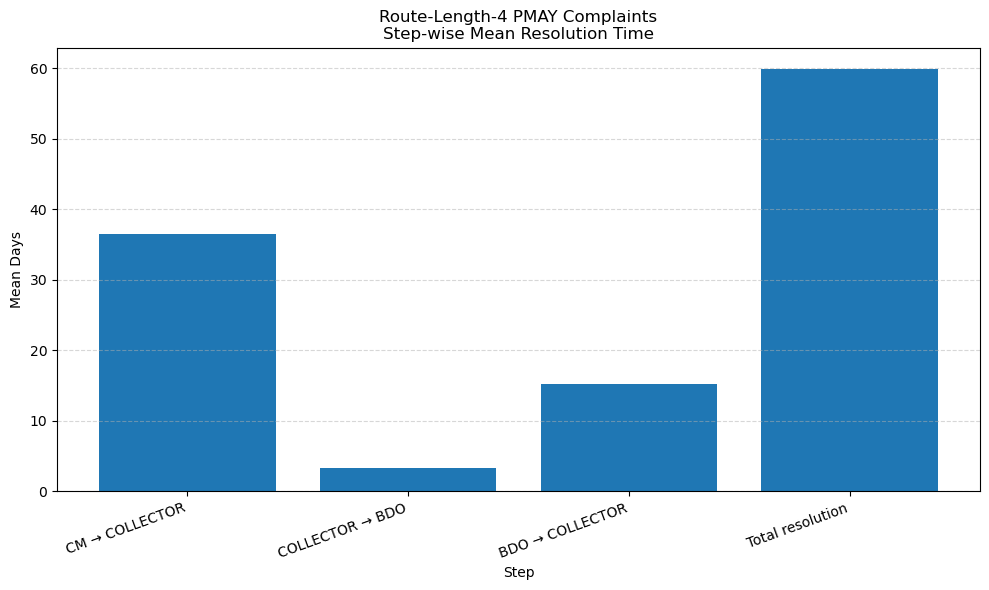

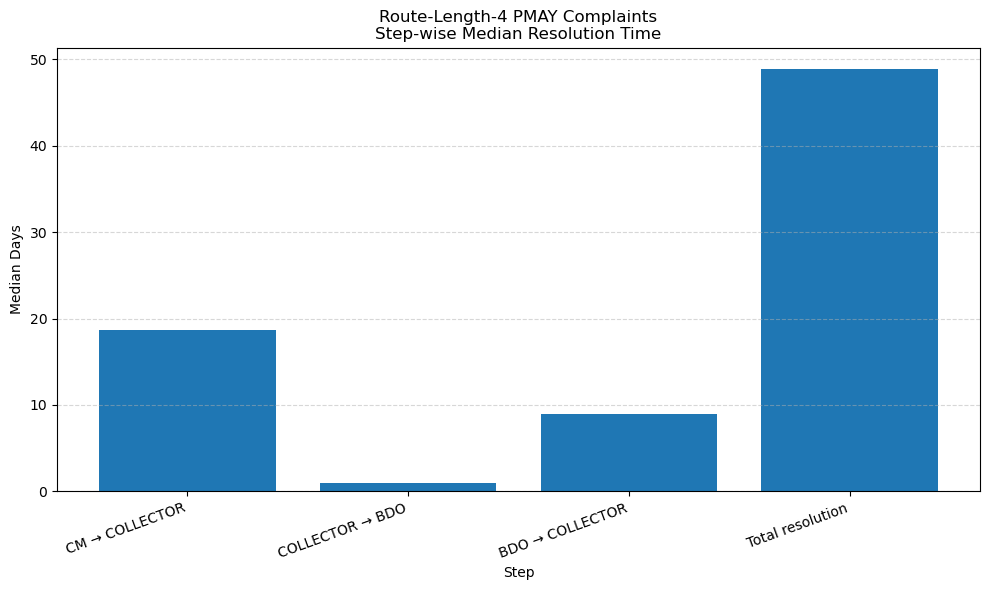

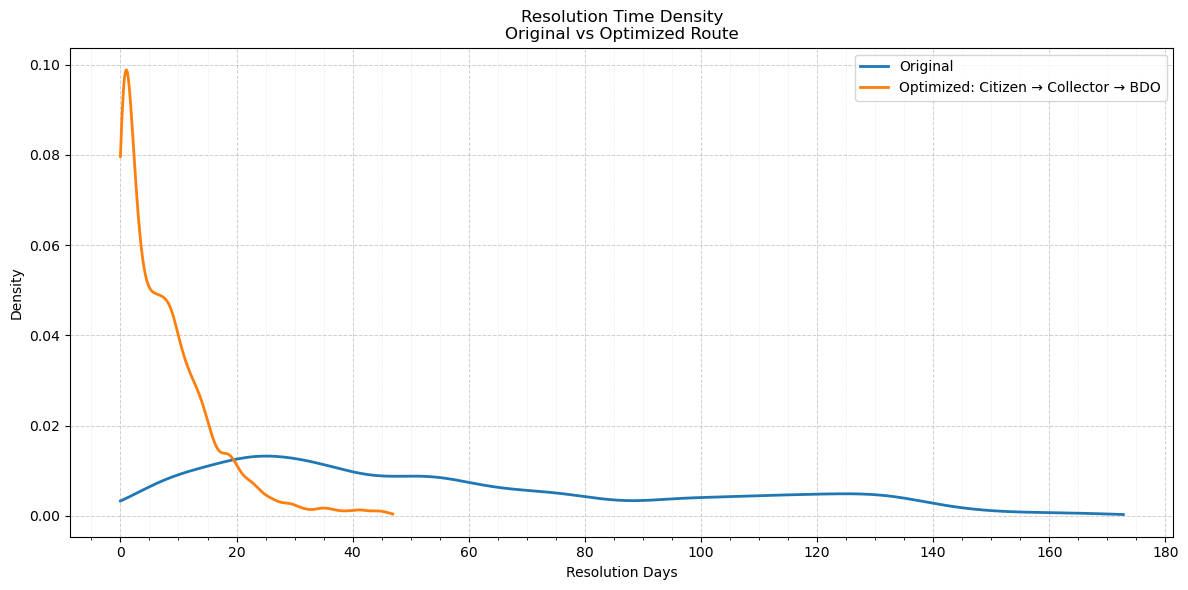

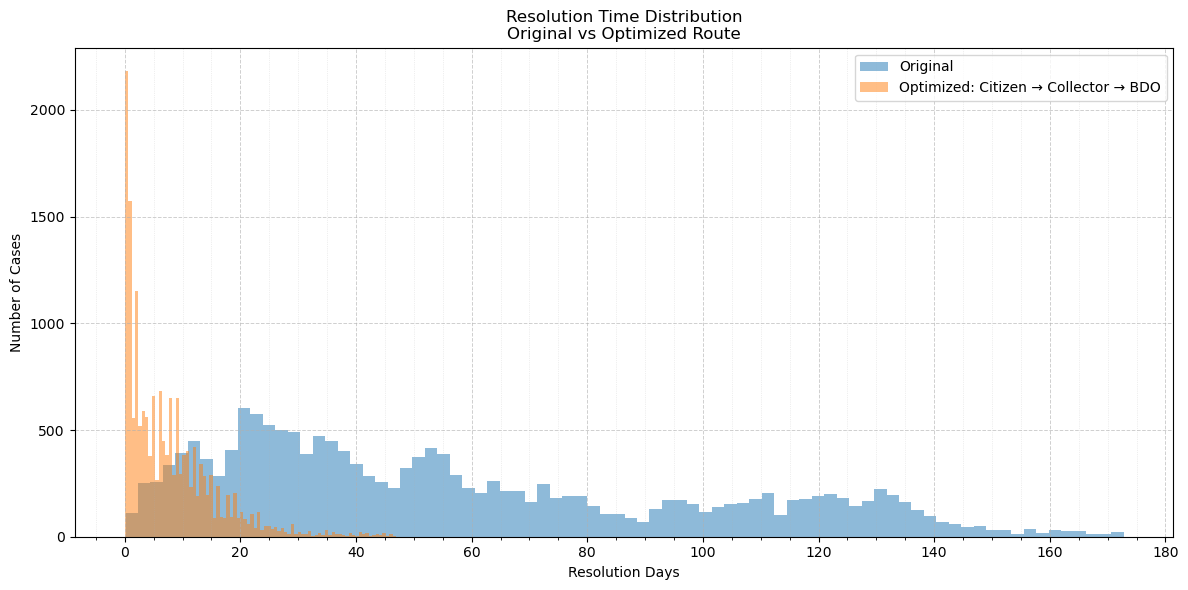

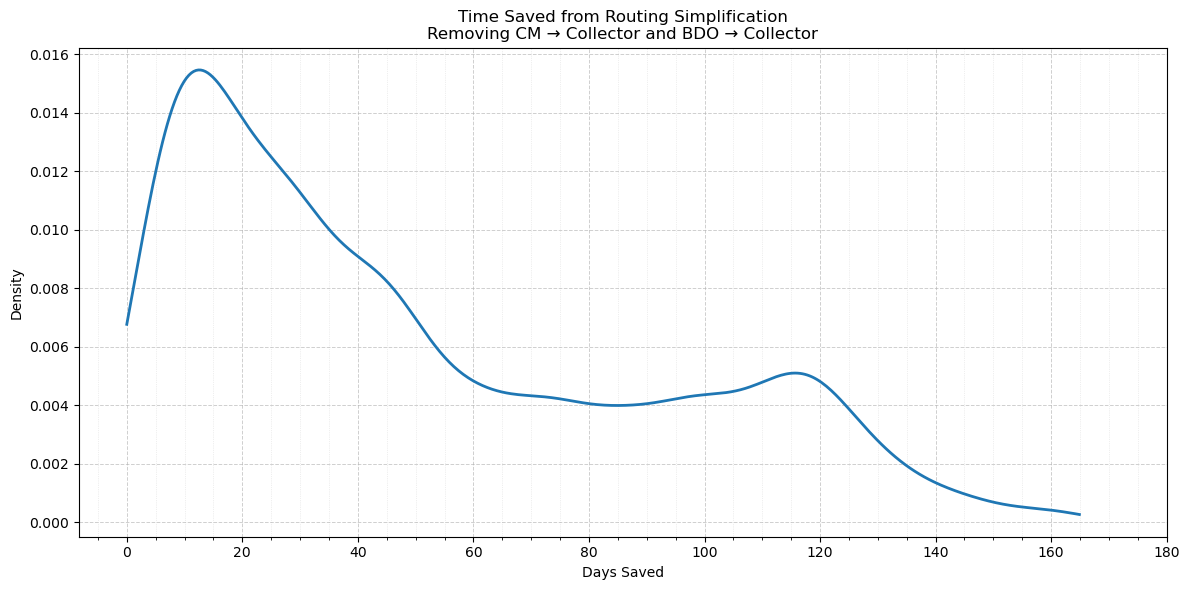

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

try:
    from scipy.stats import gaussian_kde
    USE_KDE = True
except Exception:
    USE_KDE = False

# ------------------------------------------------------------
# 1) STEP-WISE DELAY DECOMPOSITION
# ------------------------------------------------------------
step_breakup = pd.DataFrame({
    "step": [
        "CM → COLLECTOR",
        "COLLECTOR → BDO",
        "BDO → COLLECTOR",
        "Total resolution"
    ],
    "mean_days": [
        target_route["gap_1_2_days"].mean(),
        target_route["gap_2_3_days"].mean(),
        target_route["gap_3_4_days"].mean(),
        target_route["resolution_days"].mean()
    ],
    "median_days": [
        target_route["gap_1_2_days"].median(),
        target_route["gap_2_3_days"].median(),
        target_route["gap_3_4_days"].median(),
        target_route["resolution_days"].median()
    ]
}).round(2)

display(step_breakup)

plt.figure(figsize=(10, 6))
plt.bar(step_breakup["step"], step_breakup["mean_days"])
plt.ylabel("Mean Days")
plt.xlabel("Step")
plt.title("Route-Length-4 PMAY Complaints\nStep-wise Mean Resolution Time")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(step_breakup["step"], step_breakup["median_days"])
plt.ylabel("Median Days")
plt.xlabel("Step")
plt.title("Route-Length-4 PMAY Complaints\nStep-wise Median Resolution Time")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) BEFORE VS OPTIMIZED DENSITY
# ------------------------------------------------------------
old = target_route["resolution_days"].dropna().values
new = target_route["optimized_resolution_days"].dropna().values

if len(old) == 0 or len(new) == 0:
    print("No data for density plot.")
else:
    p_old = np.percentile(old, 99)
    p_new = np.percentile(new, 99)

    old_clip = old[old <= p_old]
    new_clip = new[new <= p_new]

    xmax = max(float(np.max(old_clip)), float(np.max(new_clip)))

    plt.figure(figsize=(12, 6))

    if USE_KDE and len(old_clip) > 1 and np.std(old_clip) > 0:
        grid_old = np.linspace(0, np.max(old_clip), 400)
        plt.plot(grid_old, gaussian_kde(old_clip)(grid_old),
                 linewidth=2, label="Original")
    else:
        plt.hist(old_clip, bins=40, density=True, alpha=0.4, label="Original")

    if USE_KDE and len(new_clip) > 1 and np.std(new_clip) > 0:
        grid_new = np.linspace(0, np.max(new_clip), 400)
        plt.plot(grid_new, gaussian_kde(new_clip)(grid_new),
                 linewidth=2, label="Optimized: Citizen → Collector → BDO")
    else:
        plt.hist(new_clip, bins=40, density=True, alpha=0.4,
                 label="Optimized: Citizen → Collector → BDO")

    plt.xlabel("Resolution Days")
    plt.ylabel("Density")
    plt.title("Resolution Time Density\nOriginal vs Optimized Route")
    plt.legend()
    plt.xticks(np.arange(0, xmax + 20, 20))
    plt.gca().xaxis.set_minor_locator(MultipleLocator(5))
    plt.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.6)
    plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 3) BEFORE VS OPTIMIZED HISTOGRAM
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 6))
    plt.hist(old_clip, bins=80, alpha=0.5, label="Original")
    plt.hist(new_clip, bins=80, alpha=0.5,
             label="Optimized: Citizen → Collector → BDO")
    plt.xlabel("Resolution Days")
    plt.ylabel("Number of Cases")
    plt.title("Resolution Time Distribution\nOriginal vs Optimized Route")
    plt.legend()
    plt.xticks(np.arange(0, xmax + 20, 20))
    plt.gca().xaxis.set_minor_locator(MultipleLocator(5))
    plt.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.6)
    plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 4) TIME SAVED DISTRIBUTION
# ------------------------------------------------------------
saved = target_route["saved_days"].dropna().values

if len(saved) == 0:
    print("No data for time saved plot.")
else:
    p_saved = np.percentile(saved, 99)
    saved_clip = saved[saved <= p_saved]
    xmax_saved = float(np.max(saved_clip))

    plt.figure(figsize=(12, 6))

    if USE_KDE and len(saved_clip) > 1 and np.std(saved_clip) > 0:
        grid_saved = np.linspace(0, np.max(saved_clip), 400)
        plt.plot(grid_saved, gaussian_kde(saved_clip)(grid_saved), linewidth=2)
        plt.ylabel("Density")
    else:
        plt.hist(saved_clip, bins=40, density=True)
        plt.ylabel("Density")

    plt.xlabel("Days Saved")
    plt.title("Time Saved from Routing Simplification\n"
              "Removing CM → Collector and BDO → Collector")
    plt.xticks(np.arange(0, xmax_saved + 20, 20))
    plt.gca().xaxis.set_minor_locator(MultipleLocator(5))
    plt.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.6)
    plt.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)
    plt.tight_layout()
    plt.show()